# Paired multi-model analysis

Here we will use 10X PBMCs scRNA-seq dataset from scanpy as an example to illustrate how Garfield performs scRNA-seq clustering analysis

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)

gf.__version__

'0.1.2'

In [3]:
rna = sc.read_h5ad('../Garfield_test/data/human_pbmc_10x_3k_RNA.h5ad')
rna.layers['counts'] = rna.X.copy()
rna.obs['batch'] = 'RNA'
atac = sc.read_h5ad('../Garfield_test/data/human_pbmc_10x_3k_ATAC.h5ad')
atac.layers['counts'] = atac.X.copy()
atac.obs['batch'] = 'ATAC'
mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2590 × 134920
  var:	'gene'
  2 modalities
    rna:	2590 x 36601
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
      var:	'gene'
      layers:	'counts'
    atac:	2590 x 98319
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
      var:	'gene'
      layers:	'counts'

In [4]:
# set workdir
workdir = 'result_garfield_multiome_10xpbmc3k'
gf.settings.set_workdir(workdir)

Saving results in: result_garfield_multiome_10xpbmc3k


In [5]:
gf.settings.set_figure_params(dpi=80,
                              style='white', # style must be one of white, dark, whitegrid, darkgrid, ticks
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [6]:
# make plots prettier
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [32]:
### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='multiome_10xpbmc3k',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=mdata,  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='multi-modal',
    data_type='Paired',  # Paired
    weight=0.8,
    genome=None,
    sample_col='batch',  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    rna_n_top_features=2000,
    atac_n_top_features=10000,  # INT     Number of top genes to be selected.       Default is 2000.
    metric='euclidean',  # STR     Metric for clustering.                   Default is `correlation`. euclidean

    ## Model options
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20,
    test_split=0.2,
    val_split=0.2,
    used_edge_weight=True,
    used_recon_exp=True,
    used_DSBN=False,
    used_mmd=False,
    batch_size=128,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=50,  # INT       Number of epochs.                        Default is 100.
    mmd_temperature=0.2,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    monitor_only_val_losses=False,
    learning_rate=0.001
)
dict_config = gf.settings.set_gf_params(user_config)

In [33]:
## start training
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...



Processing...


Data preprocessing and graph construction finished
Data files exist, loading...


Done!


Finished loading.

Model training.

 |█████---------------| 26.0%  - epoch_total_loss: 1710.8415527344 - epoch_vgae_loss: 0.2133009695 - epoch_instance_loss: 6.9573903084 - epoch_cluster_loss: 2.6460143328 - epoch_recon_loss: 1696.9171752930 - epoch_regu_loss: 4.1076326370 - epoch_mmd_loss: 0.0000000000 - val_total_loss: 1683.0616455078 - val_vgae_loss: 0.2830041349 - val_instance_loss: 6.4191961288 - val_cluster_loss: 2.5811135769 - val_recon_loss: 1669.7065429688 - val_regu_loss: 4.0717706680 - val_mmd_loss: 0.0000000000 - test_roc_auc: 0.5000000000 - test_precision: 0.500000000000669180

EarlyStopping: run 13 epoch
Model is saved under result_garfield_multiome_10xpbmc3k/checkpoint/model.pt.


In [34]:
import scanpy as sc
adata_final = trainer.get_latent_representation()
adata_final

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 2590 × 12000
    obs: 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nCount_peaks', 'rna:nFeature_peaks', 'rna:RNA_snn_res.1', 'rna:seurat_clusters', 'rna:celltype', 'rna:RNA.weight', 'rna:peaks.weight', 'rna:batch', 'rna:n_genes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nCount_peaks', 'atac:nFeature_peaks', 'atac:RNA_snn_res.1', 'atac:seurat_clusters', 'atac:celltype', 'atac:RNA.weight', 'atac:peaks.weight', 'atac:batch', 'atac:n_genes'
    var: 'gene', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'neighbors'
    obsm: 'X_gf'
    layers: 

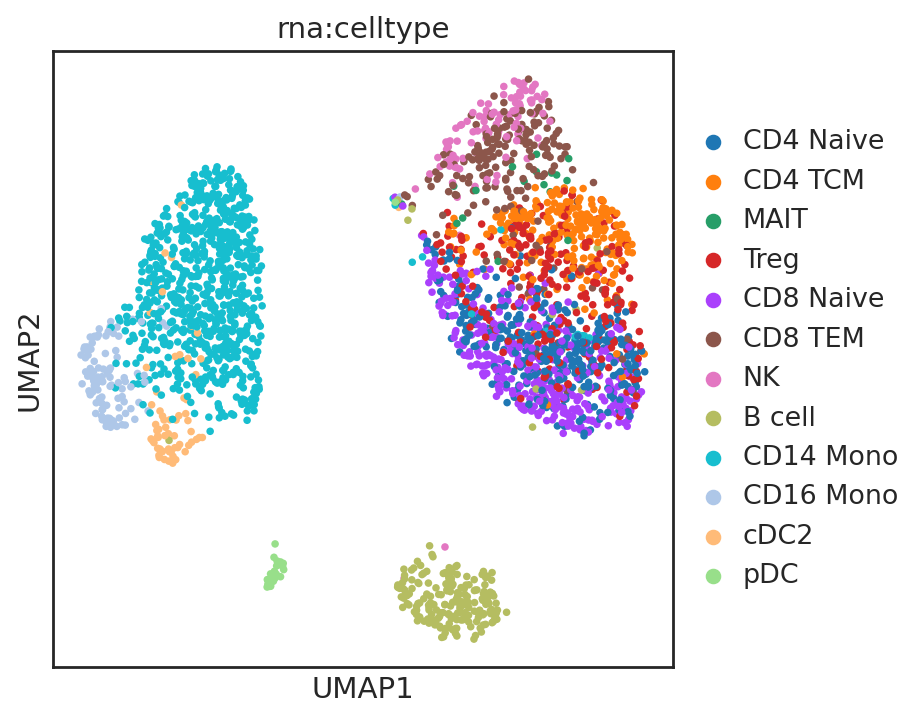

In [35]:
sc.tl.umap(adata_final)

# 创建一个matplotlib的Axes对象并设置背景颜色
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set_facecolor('white')  # 设置你喜欢的颜色
# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, ax=ax)

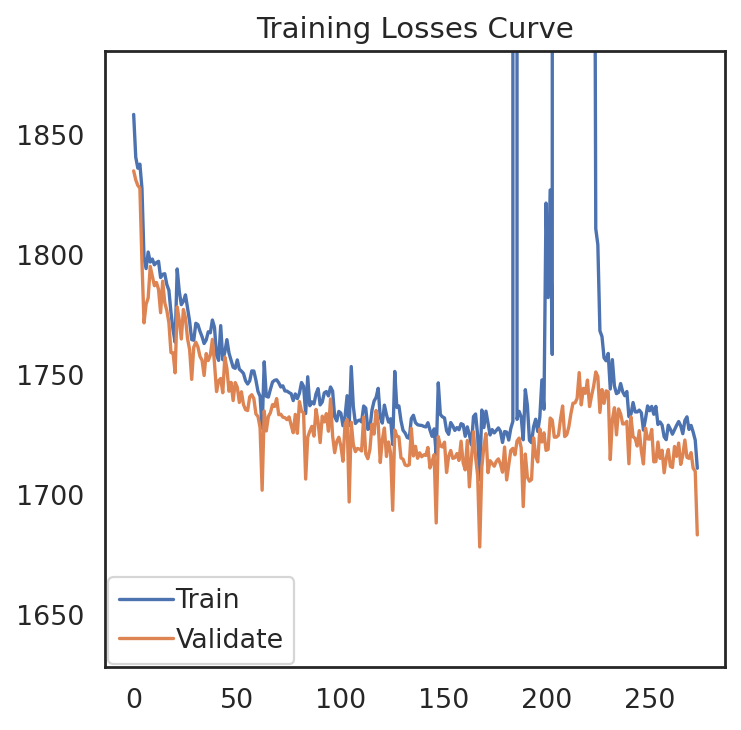

<Figure size 400x400 with 0 Axes>

In [36]:
trainer.plot_losses_curve()

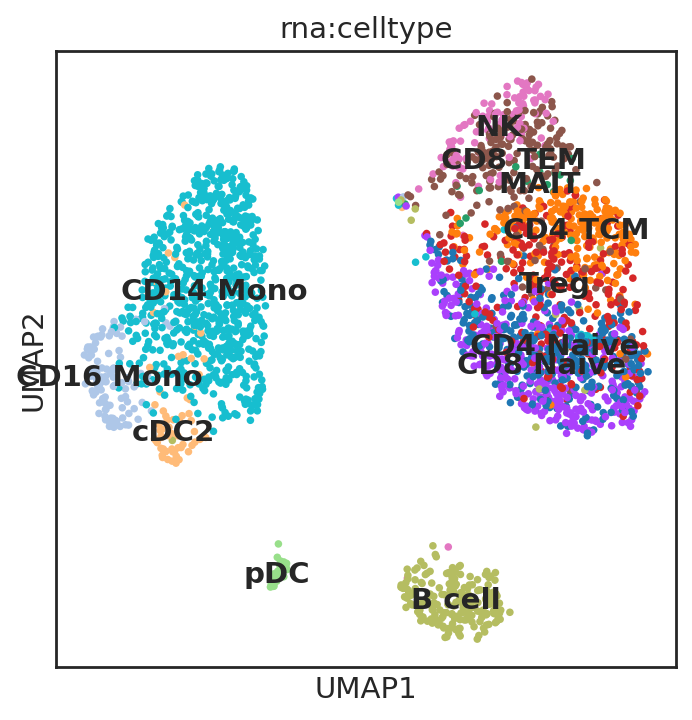

In [37]:
#设置全域sc的画图背景为白色，dpi=50分辨率
# sc.settings.set_figure_params(dpi=80, facecolor="black")

sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, legend_loc='on data',save='_pbmc3k_umap.pdf')

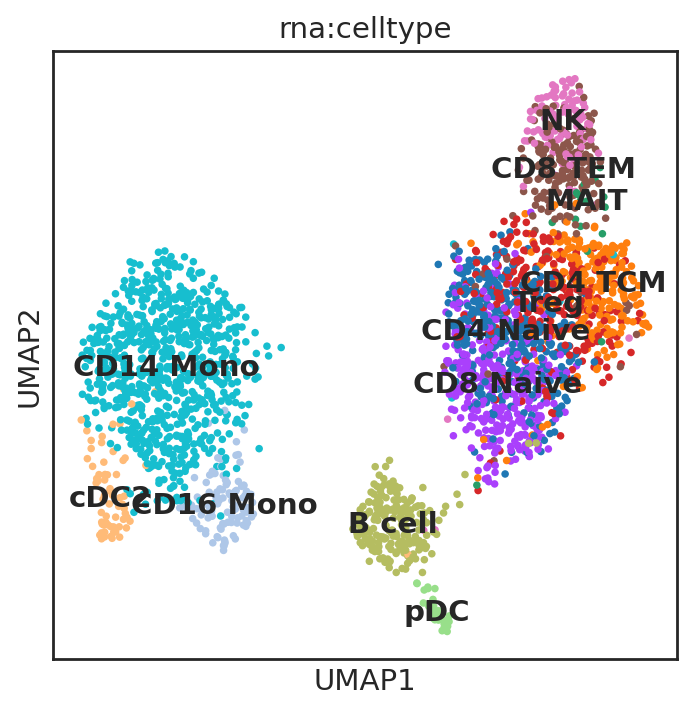

In [51]:
#设置全域sc的画图背景为白色，dpi=50分辨率
# sc.settings.set_figure_params(dpi=80, facecolor="black")

sc.pl.umap(adata_final, color=['rna:celltype'], wspace=0.15, edges=False, legend_loc='on data',save='_pbmc3k_umap.pdf')

In [38]:
sc.tl.leiden(adata_final, resolution=1.0)

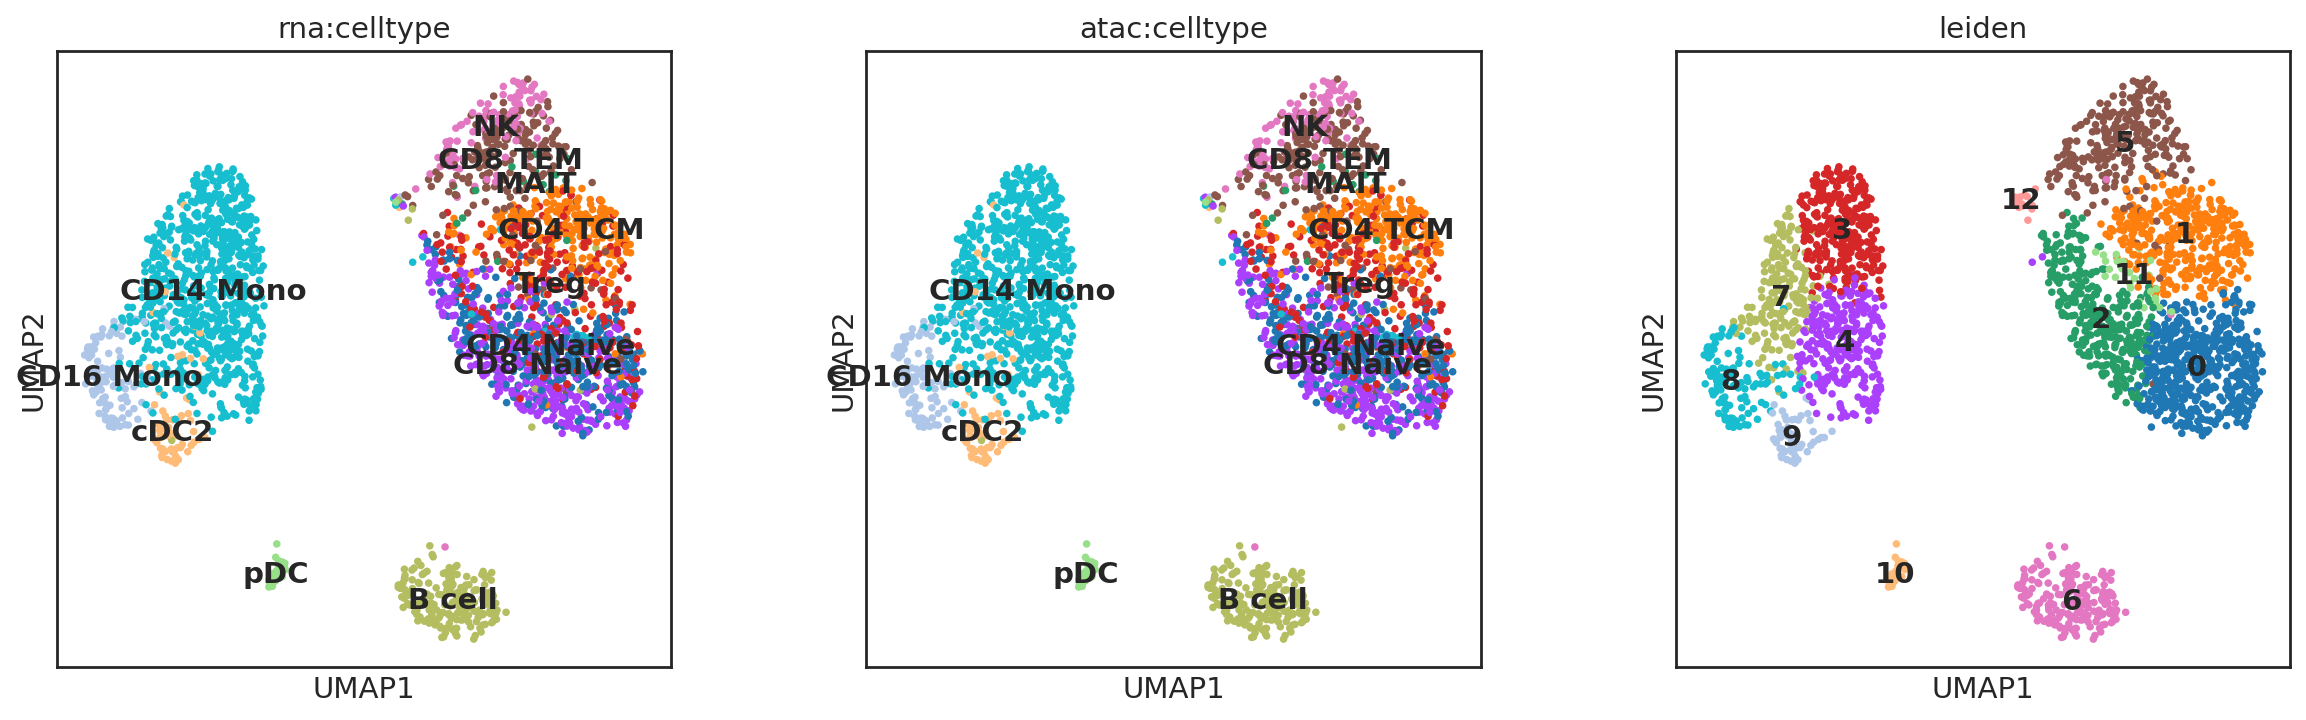

In [39]:
# adata_final.obs['celltype'] = adata_final.obs['louvain']
sc.pl.umap(adata_final, color=['rna:celltype', 'atac:celltype', 'leiden'], wspace=0.20, legend_loc='on data', edges=False, save='_multiome_10xpbmc3k.pdf')

In [ ]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD4", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]
sc.pl.dotplot(adata_final, marker_genes, groupby="celltype",standard_scale='var')
sc.pl.dotplot(adata_final, marker_genes, groupby="leiden", standard_scale='var');